In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
""" tiempo_seg = 60    
carga_proton = 1.602177e-19
protones_totales = (corriente_nA * 1e-9 / carga_proton) * tiempo_seg """

In [35]:
def leer_dosis_phits_tdeposit(filename):
    dosis = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if linea.startswith("#") or linea.startswith("'") or linea.startswith("ms") or linea.startswith("wt") or linea.startswith("\\") or linea.startswith("e:"):
                    leyendo_tabla = False
                    continue

                partes = linea.split()

                if len(partes) == 4:
                    try:
                        z_lower = float(partes[0])
                        z_upper = float(partes[1])
                        dose = float(partes[2])
                        rerr = float(partes[3])

                        dosis.append(dose)

                    except ValueError:
                        pass

    return np.array(dosis)


file_path = "histograma_dosis_M0.out"

data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

Cantidad de valores leídos: 640
Dosis mínima: 0.014254
Dosis máxima: 0.025817
Primeros valores: [0.017063 0.017185 0.0173   0.01702  0.017299 0.017397 0.017164 0.017319
 0.017582 0.017836]


In [36]:
print(len(data_dosis))

640


In [37]:
def mostrar_encabezados_phits(filename):
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if "dose" in linea.lower() or "r.err" in linea.lower():
                print(linea.strip())

In [38]:
file_path = "histograma_dosis_M0.out"
mostrar_encabezados_phits(file_path)
data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

output =  dose           # total deposit energy
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/source]
#  z-lower      z-upper        proton    r.err
y: Dose [Gy/so

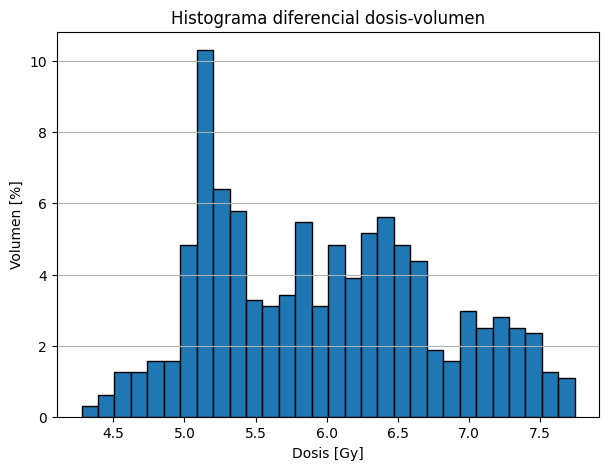

In [39]:
""" tiempo_seg = 300
data_dosis_fisica = data_dosis * tiempo_seg

n_bins = len(data_dosis_fisica)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_bins

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
) """

tiempo_seg = 300
data_dosis_fisica = data_dosis * tiempo_seg

n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_voxeles

cantidad_intervalos_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=cantidad_intervalos_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen")
plt.grid(True, axis="y")
plt.show()

In [40]:
np.min(data_dosis_fisica), np.max(data_dosis_fisica), np.mean(data_dosis_fisica)

(np.float64(4.2762), np.float64(7.7451), np.float64(5.9768784375))

In [41]:
np.std(data_dosis_fisica)/np.mean(data_dosis_fisica)

np.float64(0.13362159433094725)

In [65]:
print(data_dosis_fisica)

[5.1333 4.9896 4.9533 4.9062 4.2402 5.0838 5.0463 4.5711 5.2935 5.2653
 5.0964 5.1441 6.339  7.3146 7.2747 6.7734 6.507  8.0076 7.3581 7.1478
 7.3281 8.3553 8.6535 8.5044 6.7875 7.3395 6.714  7.683  6.1218 6.1455
 5.6694 5.9577 4.6263 5.0511 4.9704 5.0646 5.1015 5.2782 4.6167 4.7601
 6.0639 4.7991 4.7625 5.4432 4.8939 5.2953 5.3034 5.3781 5.688  6.441
 6.7164 6.5034 5.7354 6.4788 6.8001 6.9732 5.7039 6.4044 6.5178 5.994
 7.5219 8.7267 7.908  7.6944 6.5799 7.1799 7.3914 7.8006 6.3687 6.9381
 7.0446 7.4052 5.8539 5.8188 6.0615 6.3936 5.1816 5.2251 5.2413 5.1147
 4.3866 4.9509 4.8135 4.7148 6.4719 7.4094 7.9068 7.1739 5.5653 6.4434
 6.03   6.1041 6.1224 7.089  7.3572 6.7968 6.4485 6.9987 6.9597 6.8688
 6.0726 6.6777 7.1139 7.8036 7.0419 7.5486 7.8228 7.5477 6.6204 7.4115
 6.8007 7.191  6.4917 7.2714 6.8193 7.851  4.5972 4.1628 4.4559 4.2867
 5.8557 6.0654 5.2608 5.6925 6.9141 7.4412 7.5573 6.8814 5.4363 6.2445
 6.1797 5.889  6.0567 6.615  6.7779 6.5637 6.7245 7.5495 7.7232 6.2517
 5.8722 

el primer pico que vemos es debido a que en la mesh estamos agarrando aire, y como en la dosis no hay aire aparece ese pico pronunciado

In [86]:
# volumen total de la mesh: x= 3.2 * y= 2 * z= 0.2
vol_mesh_total = 3.2*2*0.2
print(f"{vol_mesh_total:.2f} cm^3")

1.28 cm^3


In [87]:
vol_pouch = 1 # (cm^3)

#entonces

vol_aire = vol_mesh_total - vol_pouch
print(f"Volumen de aire: {vol_aire:.2f} cm^3")

Volumen de aire: 0.28 cm^3


In [88]:
porcentaje_pouch = 100 * vol_pouch / vol_mesh_total
porcentaje_aire = 100 * vol_aire / vol_mesh_total

print(f"Porcentaje de pouch: {porcentaje_pouch:.2f}%")
print(f"Porcentaje de aire: {porcentaje_aire:.2f}%")    

Porcentaje de pouch: 78.12%
Porcentaje de aire: 21.88%


Este histogama nos dice qué porcentaje del volumen recibió una dosis dentro de cada intervalo

Por ejemplo: 

Entre 0.010 y 0.012 Gy/source → 20% del volumen

Entre 0.012 y 0.014 Gy/source → 35% del volumen

Entre 0.014 y 0.016 Gy/source → 25% del volumen

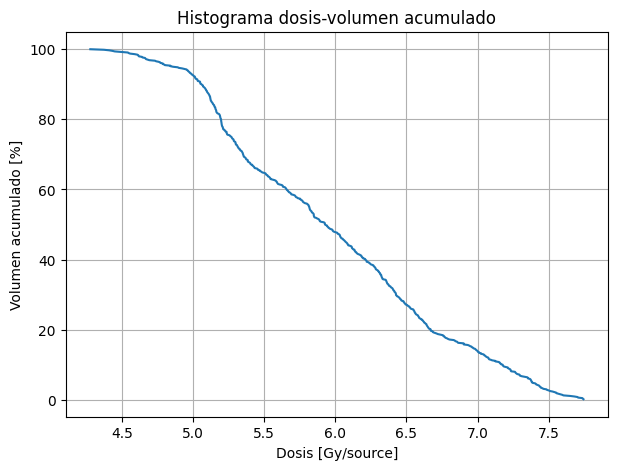

In [7]:
n_bins = len(data_dosis)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis) * volumen_por_bin

dosis_ordenada = np.sort(data_dosis)

vol_acumulado = np.array([
    np.sum(volumen_total[data_dosis >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))
plt.plot(dosis_ordenada*tiempo_seg, vol_acumulado)


plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado")
plt.grid(True)
plt.show()

Este grafico nos dice qué porcentaje del volumen recibió una dosis mayor o igual que cierto valor :

Por ejemplo:

Dosis ≥ 0.010 Gy/source → 100% del volumen

Dosis ≥ 0.012 Gy/source → 80% del volumen

Dosis ≥ 0.014 Gy/source → 45% del volumen

Dosis ≥ 0.016 Gy/source → 20% del volumen

In [90]:
nx = 16
ny = 10
nz = 4

esperados = nx * ny * nz

print("Valores esperados:", esperados)
print("Valores leídos:", len(data_dosis))

if len(data_dosis) != esperados:
    print("Ojo: no se leyó la cantidad esperada de bins.")
else:
    print("Todo ok: se leyeron todos los bins.")

Valores esperados: 640
Valores leídos: 640
Todo ok: se leyeron todos los bins.


In [ ]:
# le sacamos el aire

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

In [24]:
archivo = "histograma_dosis_M0.out"

nx = 16
ny = 10
nz = 4

xmin, xmax = -1.6, 1.6
ymin, ymax = -1.0, 1.0
zmin, zmax = 60.38, 60.58

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
z_edges = np.linspace(zmin, zmax, nz + 1)

x_centros = 0.5 * (x_edges[:-1] + x_edges[1:])
y_centros = 0.5 * (y_edges[:-1] + y_edges[1:])
z_centros = 0.5 * (z_edges[:-1] + z_edges[1:])

dosis = np.full((nx, ny, nz), np.nan)
err_rel = np.full((nx, ny, nz), np.nan)

with open(archivo, "r", encoding="utf-8", errors="ignore") as f:
    lineas = f.readlines()

ix_actual = None
iy_actual = None
leer_tabla = False
contador_z = 0

for linea in lineas:
    m = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)
    if m:
        ix_actual = int(m.group(1)) - 1
        iy_actual = int(m.group(2)) - 1
        leer_tabla = False
        contador_z = 0
        continue

    if linea.strip().startswith("#  z-lower"):
        leer_tabla = True
        contador_z = 0
        continue

    if leer_tabla:
        partes = linea.split()

        if len(partes) < 4:
            leer_tabla = False
            continue

        try:
            z_low = float(partes[0])
            z_up = float(partes[1])
            valor_dosis = float(partes[2])
            valor_err = float(partes[3])
        except ValueError:
            leer_tabla = False
            continue

        if ix_actual is not None and iy_actual is not None and contador_z < nz:
            dosis[ix_actual, iy_actual, contador_z] = valor_dosis
            err_rel[ix_actual, iy_actual, contador_z] = valor_err
            contador_z += 1

In [ ]:
# esta mascara dice: El voxel es pouch si el centro del voxel cae adentro del elipsoide

In [25]:
X, Y, Z = np.meshgrid(x_centros, y_centros, z_centros, indexing="ij")

x0 = 0.0
y0 = 0.0
z0 = 60.48

rx = 1.6
ry = 1.0
rz = 1.0

mascara_pouch = (
    ((X - x0) / rx)**2
    + ((Y - y0) / ry)**2
    + ((Z - z0) / rz)**2
) <= 1

dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)


data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]

In [93]:
print(z_centros)

[60.405 60.455 60.505 60.555]


In [ ]:
# acá data_dosis queda como un vector con solo las dosis del pouch, sin aire.

In [94]:
# para ver la matriz en la capa z= 0

print(mascara_pouch[:, :, 0])

[[False False False  True  True  True  True False False False]
 [False False  True  True  True  True  True  True False False]
 [False  True  True  True  True  True  True  True  True False]
 [False  True  True  True  True  True  True  True  True False]
 [False  True  True  True  True  True  True  True  True False]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [False  True  True  True  True  True  True  True  True False]
 [False  True  True  True  True  True  True  True  True False]
 [False  True  True  True  True  True  True  True  True False]
 [False False  True  True  True  True  True  True False False]
 [False False False  True  True  True  True False False

In [26]:
dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

data_dosis = dosis_sin_aire[~np.isnan(dosis_sin_aire)]

print("Cantidad de voxeles dentro del pouch:", len(data_dosis))
print("Dosis mínima dentro del pouch:", np.min(data_dosis))
print("Dosis máxima dentro del pouch:", np.max(data_dosis))

Cantidad de voxeles dentro del pouch: 512
Dosis mínima dentro del pouch: 0.014254
Dosis máxima dentro del pouch: 0.025817


In [ ]:
# da aprox el 80%

In [27]:
datos = []

for ix in range(nx):
    for iy in range(ny):
        for iz in range(nz):
            if mascara_pouch[ix, iy, iz]:
                datos.append([
                    ix + 1,
                    iy + 1,
                    iz + 1,
                    x_centros[ix],
                    y_centros[iy],
                    z_centros[iz],
                    dosis[ix, iy, iz],
                    err_rel[ix, iy, iz]
                ])

df_pouch = pd.DataFrame(
    datos,
    columns=["ix", "iy", "iz", "x", "y", "z", "dosis_Gy_source", "err_rel"]
)

df_pouch.head()

,ix,iy,iz,x,y,z,dosis_Gy_source,err_rel
0,1,4,1,-1.5,-0.3,60.405,0.020300,0.0087
1,1,4,2,-1.5,-0.3,60.455,0.022169,0.0086
2,1,4,3,-1.5,-0.3,60.505,0.022457,0.0088
3,1,4,4,-1.5,-0.3,60.555,0.022642,0.0093
4,1,5,1,-1.5,-0.1,60.405,0.021848,0.0076


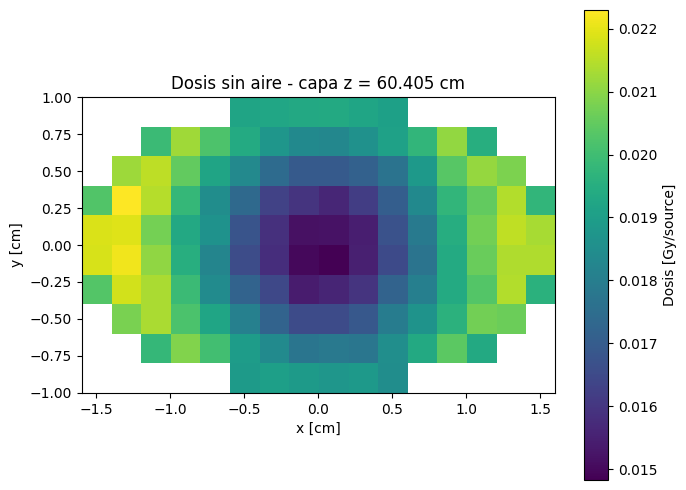

In [28]:
iz = 0

plt.figure(figsize=(7, 5))

plt.imshow(
    dosis_sin_aire[:, :, iz].T,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="equal"
)

plt.colorbar(label="Dosis [Gy/source]")
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title(f"Dosis sin aire - capa z = {z_centros[iz]:.3f} cm")
plt.tight_layout()
plt.show()

In [ ]:
# esto para graficar todas las capas en z
"""
for iz in range(nz):
    plt.figure(figsize=(7, 5))

    plt.imshow(
        dosis_sin_aire[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal"
    )

    plt.colorbar(label="Dosis [Gy/source]")
    plt.xlabel("x [cm]")
    plt.ylabel("y [cm]")
    plt.title(f"Dosis sin aire - z = {z_centros[iz]:.3f} cm")
    plt.tight_layout()
    plt.show()

"""

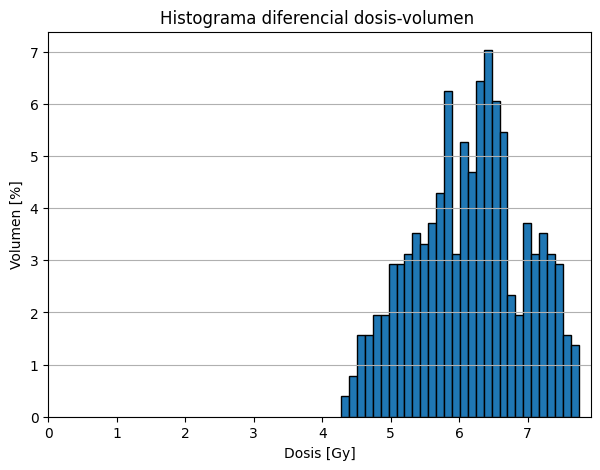

In [29]:
tiempo_seg = 300

data_dosis_fisica = data_dosis * tiempo_seg

n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No hay voxeles del pouch en las primeras 2 capas z.")

volumen_por_voxel = 100.0 / n_voxeles

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen ")
plt.xlim(left=0)
plt.grid(True, axis="y")
plt.show()

In [34]:
np.min(data_dosis_fisica), np.max(data_dosis_fisica), np.mean(data_dosis_fisica)

(np.float64(4.2762), np.float64(7.7451), np.float64(6.150933984375))

In [32]:
np.std(data_dosis_fisica)/np.mean(data_dosis_fisica)

np.float64(0.12898142770629134)

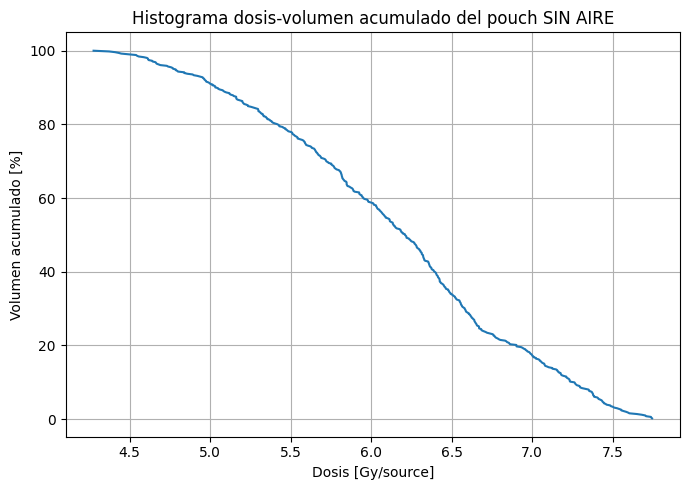

In [33]:
n_bins = len(data_dosis)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo o la máscara del pouch.")

volumen_por_bin = 100.0 / n_bins
volumen_total = np.ones_like(data_dosis) * volumen_por_bin

dosis_ordenada = np.sort(data_dosis)

vol_acumulado = np.array([
    np.sum(volumen_total[data_dosis >= d])
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))

plt.plot(dosis_ordenada*tiempo_seg, vol_acumulado)

plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado del pouch SIN AIRE")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────
# Índice de homogeneidad: (D2 - D98) / D2
# ─────────────────────────────────────────────

dosis_gy = dosis_ordenada * tiempo_seg  # dosis en Gy (igual que en el plot)

# Invertimos para que np.interp funcione (volumen va de 100 a 0)
vol_inv  = vol_acumulado[::-1]
dosis_inv = dosis_gy[::-1]

D2  = np.interp(2,  vol_inv, dosis_inv)
D98 = np.interp(98, vol_inv, dosis_inv)

HI = (D2 - D98) / D2

print(f"D2  = {D2:.3f} Gy")
print(f"D98 = {D98:.3f} Gy")
print(f"HI  = {HI:.4f}") 

D2  = 7.940 Gy
D98 = 4.245 Gy
HI  = 0.4654


In [73]:
dosis_sin_aire = np.where(mascara_pouch, dosis, np.nan)
err_sin_aire = np.where(mascara_pouch, err_rel, np.nan)

dosis_primeras_2_capas = dosis_sin_aire[:, :, :2]
err_primeras_2_capas = err_sin_aire[:, :, :2]

data_dosis = dosis_primeras_2_capas[~np.isnan(dosis_primeras_2_capas)]
data_err = err_primeras_2_capas[~np.isnan(err_primeras_2_capas)]

print("Cantidad de voxeles dentro del pouch en las primeras 2 capas z:", len(data_dosis))
print("Dosis mínima dentro del pouch en las primeras 2 capas z:", np.min(data_dosis))
print("Dosis máxima dentro del pouch en las primeras 2 capas z:", np.max(data_dosis))
print("Dosis media dentro del pouch en las primeras 2 capas z:", np.mean(data_dosis))

print("Error relativo medio en las primeras 2 capas z:", np.mean(data_err))
print("Error relativo máximo en las primeras 2 capas z:", np.max(data_err))

Cantidad de voxeles dentro del pouch en las primeras 2 capas z: 256
Dosis mínima dentro del pouch en las primeras 2 capas z: 0.01318
Dosis máxima dentro del pouch en las primeras 2 capas z: 0.029089
Dosis media dentro del pouch en las primeras 2 capas z: 0.02039018359375
Error relativo medio en las primeras 2 capas z: 0.08392773437500001
Error relativo máximo en las primeras 2 capas z: 0.1034


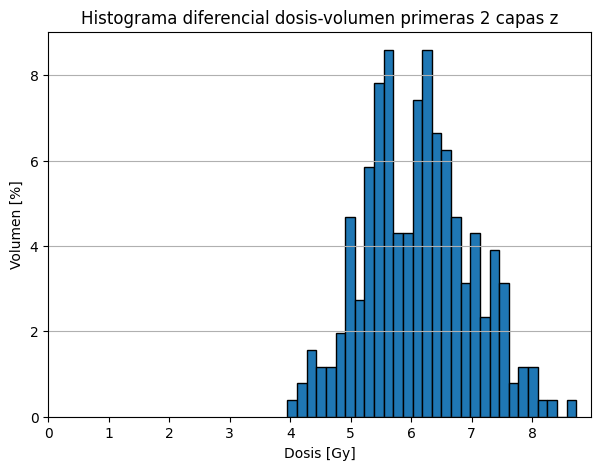

In [74]:
tiempo_seg = 300

data_dosis_fisica = data_dosis * tiempo_seg

n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No hay voxeles del pouch en las primeras 2 capas z.")

volumen_por_voxel = 100.0 / n_voxeles

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen primeras 2 capas z")
plt.xlim(left=0)
plt.grid(True, axis="y")
plt.show()

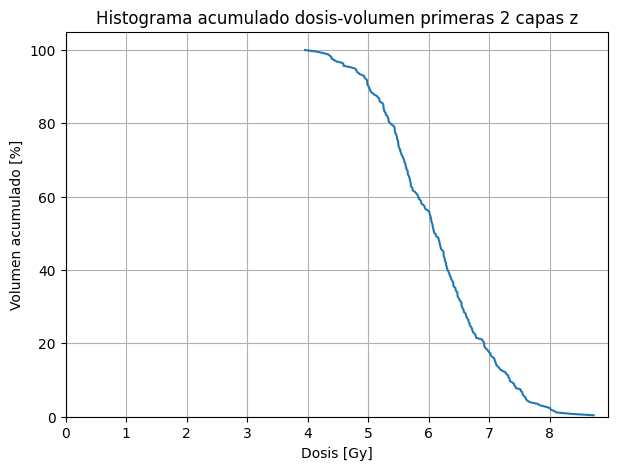

In [76]:
tiempo_seg = 300

data_dosis_fisica = data_dosis * tiempo_seg

n_voxeles = len(data_dosis_fisica)

if n_voxeles == 0:
    raise ValueError("No hay voxeles del pouch en las primeras 2 capas z.")

volumen_por_voxel = 100.0 / n_voxeles

dosis_ordenada = np.sort(data_dosis_fisica)

vol_acumulado = np.array([
    np.sum(data_dosis_fisica >= d) * volumen_por_voxel
    for d in dosis_ordenada
])

plt.figure(figsize=(7, 5))
plt.plot(dosis_ordenada, vol_acumulado)

plt.xlabel("Dosis [Gy]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma acumulado dosis-volumen primeras 2 capas z")
plt.xlim(left=0)
plt.ylim(0, 105)
plt.grid(True)
plt.show()

In [77]:
np.min(data_dosis_fisica), np.max(data_dosis_fisica), np.mean(data_dosis_fisica)

(np.float64(3.954), np.float64(8.7267), np.float64(6.117055078125))

In [78]:
np.std(data_dosis_fisica), np.mean(data_dosis_fisica)

(np.float64(0.8836725651926809), np.float64(6.117055078125))

In [79]:
0.8836725651926809/6.117055078125

0.14446045587406156

## Cálculo del volumen del pouch cortado




El pouch se modeló en PHITS como un elipsoide:

`100 ell 0.0 0.0 61.01  1.6 0.0 0.0  -1.0`

y fue recortado por los planos:

`201 pz 60.58`

`202 pz 60.78`

Interpretamos entonces un elipsoide centrado en:

$$
z_0 = 61.01 \ \mathrm{cm}
$$

con semiejes:

$$
a_x = 1.6 \ \mathrm{cm}
$$

$$
a_y = 1.0 \ \mathrm{cm}
$$

$$
a_z = 1.0 \ \mathrm{cm}
$$

La ecuación del elipsoide es:

$$
\frac{x^2}{a_x^2}
+
\frac{y^2}{a_y^2}
+
\frac{(z-z_0)^2}{a_z^2}
\leq 1
$$

es decir:

$$
\frac{x^2}{1.6^2}
+
\frac{y^2}{1.0^2}
+
\frac{(z-61.01)^2}{1.0^2}
\leq 1
$$

Los planos de corte limitan el volumen entre:

$$
z_1 = 60.58 \ \mathrm{cm}
$$

$$
z_2 = 60.78 \ \mathrm{cm}
$$

Para un valor fijo de $z$, la sección transversal del elipsoide es una elipse. Su área depende de qué tan lejos estemos del centro del elipsoide.

La ecuación del elipsoide se puede escribir como:

$$
\frac{x^2}{a_x^2}
+
\frac{y^2}{a_y^2}
\leq
1-
\frac{(z-z_0)^2}{a_z^2}
$$

Entonces, a cada altura $z$, los semiejes de la sección elíptica quedan reducidos por el factor:

$$
\sqrt{
1-
\frac{(z-z_0)^2}{a_z^2}
}
$$

Por lo tanto, el área de la sección transversal es:

$$
A(z)
=
\pi a_x a_y
\left[
1-
\frac{(z-z_0)^2}{a_z^2}
\right]
$$

El volumen del pouch cortado se calcula integrando esa área entre los planos de corte:

$$
V
=
\int_{z_1}^{z_2}
A(z)\,dz
$$

Reemplazando $A(z)$:

$$
V
=
\int_{z_1}^{z_2}
\pi a_x a_y
\left[
1-
\frac{(z-z_0)^2}{a_z^2}
\right]
dz
$$

Sacando las constantes fuera de la integral:

$$
V
=
\pi a_x a_y
\int_{z_1}^{z_2}
\left[
1-
\frac{(z-z_0)^2}{a_z^2}
\right]
dz
$$

La integral es:

$$
V
=
\pi a_x a_y
\left[
(z-z_0)
-
\frac{(z-z_0)^3}{3a_z^2}
\right]_{z_1}^{z_2}
$$

Reemplazando los valores:

$$
V
=
\pi (1.6)(1.0)
\left[
(z-61.01)
-
\frac{(z-61.01)^3}{3(1.0)^2}
\right]_{60.58}^{60.78}
$$

Definimos:

$$
u = z-z_0
$$

Entonces:

$$
u_1 = z_1-z_0
$$

$$
u_1 = 60.58-61.01
$$

$$
u_1 = -0.43 \ \mathrm{cm}
$$

y:

$$
u_2 = z_2-z_0
$$

$$
u_2 = 60.78-61.01
$$

$$
u_2 = -0.23 \ \mathrm{cm}
$$

Entonces el volumen queda:

$$
V
=
\pi (1.6)(1.0)
\left[
u-\frac{u^3}{3}
\right]_{-0.43}^{-0.23}
$$

Evaluamos en el extremo superior:

$$
u_2-\frac{u_2^3}{3}
=
-0.23-\frac{(-0.23)^3}{3}
$$

$$
u_2-\frac{u_2^3}{3}
=
-0.23-\frac{-0.012167}{3}
$$

$$
u_2-\frac{u_2^3}{3}
=
-0.23+0.004056
$$

$$
u_2-\frac{u_2^3}{3}
=
-0.225944
$$

Evaluamos en el extremo inferior:

$$
u_1-\frac{u_1^3}{3}
=
-0.43-\frac{(-0.43)^3}{3}
$$

$$
u_1-\frac{u_1^3}{3}
=
-0.43-\frac{-0.079507}{3}
$$

$$
u_1-\frac{u_1^3}{3}
=
-0.43+0.026502
$$

$$
u_1-\frac{u_1^3}{3}
=
-0.403498
$$

Restamos ambos valores:

$$
\left[
u-\frac{u^3}{3}
\right]_{-0.43}^{-0.23}
=
-0.225944 - (-0.403498)
$$

$$
\left[
u-\frac{u^3}{3}
\right]_{-0.43}^{-0.23}
=
0.177554
$$

Entonces:

$$
V
=
\pi (1.6)(1.0)(0.177554)
$$

$$
V
=
0.8925 \ \mathrm{cm^3}
$$

Por lo tanto, el volumen aproximado del pouch cortado es:

$$
\boxed{
V_{\mathrm{pouch}} \approx 0.89 \ \mathrm{cm^3}
}
$$